# Грибы Лордерона

После того как от земель Лордерона отступила чума, Отрекшиеся решили заняться обычными крестьянскими делами — восстановлением хозяйства и сбором урожая для торговли. Леса Лордерона издавна славились своими грибами, однако чума не прошла для них бесследно: многие грибы изменились и стали непригодны для употребления.

Чтобы не рисковать урожаем и не допустить попадания опасных грибов на рынки, травники Отрекшихся начали внимательно исследовать найденные экземпляры. Для каждого гриба они записывали его внешний вид, размеры, форму и цвет различных частей, место произрастания и другие характеристики.

Так травники собрали большой датасет грибов Лордерона. Теперь необходимо помочь им определить, какие грибы пригодны для сбора и торговли, а какие после воздействия чумы стали опасными.

> **Калия Менетилл, член Мрачносовета**
>
> — Многое из того, что было известно нашим травникам о землях Лордерона, погибло вместе с Третьей войной. Старые записи сгорели, архивы были разграблены, а те, кто хранил эти знания, погибли или покинули наши земли. Поэтому собрать полную информацию о грибах Лордерона нам так и не удалось. Некоторые характеристики удалось восстановить по сохранившимся записям, другие травники определяли самостоятельно, а о некоторых экземплярах сведений и вовсе не осталось. Теперь нам предстоит разобраться с тем, что удалось собрать, и понять, какие знания все еще можно восстановить. Да хранит нас Свет.

# Оглавление

- [Постановка задачи](#постановка-задачи)
- [Описание данных](#описание-данных)
- [Фиксация окружения](#фиксация-окружения)
- [1. Предварительная обработка данных](#1-предварительная-обработка-данных)
    - [1.1. Чтение и загрузка данных](#11-чтение-и-загрузка-данных)
    - [1.2. Первичный анализ данных](#12-первичный-анализ-данных)
    - [1.3. Разделение выборки на обучающую и тестовую выборки](#13-разделение-выборки-на-обучающую-и-тестовую-выборки)
    - [1.4. Обработка вещественных признаков (заполнение пропусков)](#14-обработка-вещественных-признаков-заполнение-пропусков)
    - [1.5. Кодирование категориальных признаков](#15-кодирование-категориальных-признаков)
    - [1.6. Детекция выбросов и аномалий в данных](#16-детекция-выбросов-и-аномалий-в-данных)
    - [1.7. Подведение итогов раздела 1](#17-подведение-итогов-раздела-1)
- [2. Генерация новых признаков](#2-генерация-новых-признаков)
- [3. Выбор моделей ML и метрик](#3-выбор-моделей-ml-и-метрик)
- [4. Обучение моделей ML и подбор гиперпараметров](#4-обучение-моделей-ml-и-подбор-гиперпараметров)
- [5. Вычисление метрик на новых данных](#5-вычисление-метрик-на-новых-данных)
- [6. Результат работы](#6-результат-работы)

# Постановка задачи

Травники Отрекшихся собрали датасет грибов Лордерона после чумы: многие грибы изменились и стали опасными. Нужно определить, какие грибы пригодны для сбора и торговли.

- **Задача:** бинарная классификация, ядовитый гриб (`p`) или съедобный (`e`).
- **Объект:** один гриб.
- **Входные данные:** внешний вид (шляпка, пластинки, ножка, покрывало, кольцо), размеры и место произрастания.
- **Образ результата модели:** метка класса `class`: `p` или `e`.

## Анализ предметной области

- Главный риск заказчика: опасный гриб попадёт на рынок. Ядовитый гриб, принятый за съедобный, хуже, чем съедобный, принятый за ядовитый.
- Данные неполные: часть записей сгорела или не сохранилась, часть признаков травники определяли сами, поэтому в данных будут пропуски.

# Описание данных

Датасет с признаками грибов. Нужно определить, **ядовитый** гриб или **съедобный**.

## Целевая переменная

| Столбец | Ожидаемый тип | Описание | Значения |
|---|---|---|---|
| `class` | category | Класс гриба (бинарный) | ядовитый = `p`, съедобный = `e` |

## Признаки

Тип данных: `float`: числовой признак, `category`: категориальный (номинальный) признак.

| Столбец | Ожидаемый тип | Описание | Значения |
|---|---|---|---|
| `cap-diameter` | float | Диаметр шляпки, см | число |
| `cap-shape` | category | Форма шляпки | колокольчатая = `b`, коническая = `c`, выпуклая = `x`, плоская = `f`, вогнутая = `s`, шарообразная = `p`, другая = `o` |
| `cap-surface` | category | Поверхность шляпки | волокнистая = `i`, бороздчатая = `g`, чешуйчатая = `y`, гладкая = `s`, блестящая = `h`, кожистая = `l`, шелковистая = `k`, липкая = `t`, морщинистая = `w`, мясистая = `e`, сухая = `d` |
| `cap-color` | category | Цвет шляпки | коричневый = `n`, бежевый = `b`, серый = `g`, зелёный = `r`, розовый = `p`, фиолетовый = `u`, красный = `e`, белый = `w`, жёлтый = `y`, синий = `l`, оранжевый = `o`, чёрный = `k` |
| `does-bruise-or-bleed` | category | Темнеет при надавливании или выделяет сок | да = `t`, нет = `f` |
| `gill-attachment` | category | Прикрепление пластинок | приросшие = `a`, выемчатые = `x`, нисходящие = `d`, свободные = `e`, извилистые = `s`, поры = `p`, нет = `f`, неизвестно = `?` |
| `gill-spacing` | category | Расстояние между пластинками | частые = `c`, редкие = `d`, нет = `f` |
| `gill-color` | category | Цвет пластинок | как `cap-color` + нет = `f` |
| `stem-height` | float | Высота ножки, см | число |
| `stem-width` | float | Ширина ножки, мм | число |
| `stem-root` | category | Основание ножки | луковичное = `b`, вздутое = `s`, булавовидное = `c`, чашевидное = `u`, ровное = `e`, ризоморфы = `z`, укоренённое = `r`, ножки нет = `f` |
| `stem-surface` | category | Поверхность ножки | как `cap-surface` + нет = `f` |
| `stem-color` | category | Цвет ножки | как `cap-color` + нет = `f` |
| `veil-type` | category | Тип покрывала | частичное = `p`, общее = `u` |
| `veil-color` | category | Цвет покрывала | как `cap-color` + нет = `f` |
| `has-ring` | category | Наличие кольца | есть = `t`, нет = `f` |
| `ring-type` | category | Тип кольца | паутинистое = `c`, исчезающее = `e`, расширяющееся = `r`, бороздчатое = `g`, большое = `l`, висячее = `p`, чехловидное = `s`, зональное = `z`, чешуйчатое = `y`, подвижное = `m`, нет = `f`, неизвестно = `?` |
| `spore-print-color` | category | Цвет споровой массы | как `cap-color` |
| `habitat` | category | Место произрастания | трава = `g`, листва = `l`, луга = `m`, тропинки = `p`, пустоши = `h`, город = `u`, пустыри = `w`, лес = `d` |
| `season` | category | Сезон | весна = `s`, лето = `u`, осень = `a`, зима = `w` |

# Фиксация окружения

Фиксируем версию Python, версии библиотек, основные импорты и случайный сид.

In [69]:
import platform
import warnings
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("seed:", SEED)

Python: 3.14.8
pandas: 3.0.6
numpy: 2.5.3
matplotlib: 3.11.2
scikit-learn: 1.9.1
seed: 42


# 1. Предварительная обработка данных

## 1.1. Чтение и загрузка данных 

In [70]:
df = pd.read_csv("warcraft_semicolon.csv", sep=";")
df.head()

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,...,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,class
0,15.26,x,g,o,f,e,NaN,w,16.95,17.09,...,y,w,u,w,t,g,NaN,d,w,p
1,16.60,x,g,o,f,e,NaN,w,17.99,18.19,...,y,w,u,w,t,g,NaN,d,u,p
2,14.07,x,g,o,f,e,NaN,w,17.80,17.74,...,y,w,u,w,t,g,NaN,d,w,p
3,14.17,f,h,e,f,e,NaN,w,NaN,15.98,...,y,w,u,w,t,p,NaN,d,w,p
4,14.64,x,h,o,f,e,NaN,w,16.53,17.20,...,y,w,u,w,t,p,NaN,d,w,p


## 1.2. Первичный анализ данных

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cap-diameter          61069 non-null  float64
 1   cap-shape             61069 non-null  str    
 2   cap-surface           46949 non-null  str    
 3   cap-color             61069 non-null  str    
 4   does-bruise-or-bleed  61069 non-null  str    
 5   gill-attachment       51185 non-null  str    
 6   gill-spacing          36006 non-null  str    
 7   gill-color            61069 non-null  str    
 8   stem-height           51909 non-null  float64
 9   stem-width            54351 non-null  float64
 10  stem-root             9531 non-null   str    
 11  stem-surface          22945 non-null  str    
 12  stem-color            61069 non-null  str    
 13  veil-type             3177 non-null   str    
 14  veil-color            7413 non-null   str    
 15  has-ring              61069 no

In [72]:
df.duplicated().sum()

np.int64(96)

In [73]:
missing = df.isna().sum()
pd.DataFrame({
    "пропусков": missing,
    "доля, %": (missing / len(df) * 100).round(2),
}).sort_values("пропусков", ascending=False)

,пропусков,"доля, %"
veil-type,57892,94.80
spore-print-color,54715,89.60
veil-color,53656,87.86
stem-root,51538,84.39
stem-surface,38124,62.43
gill-spacing,25063,41.04
cap-surface,14120,23.12
gill-attachment,9884,16.18
stem-height,9160,15.00
stem-width,6718,11.00


In [74]:
df["class"].value_counts(normalize=True).mul(100).round(2)

class
p    55.49
e    44.51
Name: proportion, dtype: float64

**Присутствует 96 строк полных дубликатов.** На этапе предобработки их следует удалить.

**Дисбаланс классов незначителен**, практически отсутствует. Ядовитых грибов (`p`) 55.5 %, съедобных (`e`) 44.5 %. Перекос небольшой, поэтому балансировать классы (oversampling, веса классов) не нужно.

Чтобы соотношение классов в обучающей и тестовой выборках совпадало с исходным, при разделении будем использовать стратификацию по `class`.

Для заказчика ошибки неравноценны: съедобный гриб, принятый за ядовитый, означает потерю урожая, а ядовитый, принятый за съедобный, означает угрозу здоровью покупателей. Поэтому одной accuracy при оценке моделей недостаточно, особенно важна полнота (recall) по классу `p`.

Пропуски есть в большинстве признаков. Больше 80 % значений не хватает в `veil-type`, `spore-print-color`, `veil-color` и `stem-root`: эти признаки почти пустые, и их, скорее всего, придётся удалить. Умеренные пропуски (11–62 %) есть в `stem-surface`, `gill-spacing`, `cap-surface`, `gill-attachment`, а также в числовых `stem-height` и `stem-width`. Эти признаки будем заполнять на этапе предобработки данных.

In [75]:
veil = df["veil-type"]

print("Уникальные значения:", veil.dropna().unique())
print(f"Пропусков: {veil.isna().sum()} из {len(df)} ({veil.isna().mean() * 100:.1f} %)")

pd.crosstab(veil.isna(), df["class"], normalize="index").mul(100).round(1)


Уникальные значения: <StringArray>
['u']
Length: 1, dtype: str
Пропусков: 57892 из 61069 (94.8 %)


class,e,p
veil-type,,
False,33.3,66.7
True,45.1,54.9


Признак `veil-type` принимает единственное значение `u` и пропущен в 94.8 % строк, поэтому по своему значению не помогает отличить ядовитый гриб от съедобного.

Сам факт пропуска слабо связан с классом: среди грибов с заполненным `veil-type` ядовитых 66.7 %, среди остальных 54.9 %. Но заполнен признак лишь у 5 % строк, и наличие покрывала, вероятно, уже отражено в `veil-color`, поэтому отдельный признак «пропуск» не создаём.

**Признак неинформативен и будет удалён на этапе обработки данных.**


In [76]:
df[(df["stem-root"] == "f") & ((df["stem-height"] != 0) | (df["stem-width"] != 0))]

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,...,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,class
56481,4.29,o,t,w,f,NaN,c,w,0.0,NaN,...,f,f,NaN,NaN,f,f,n,d,u,p
56495,4.27,o,s,w,f,NaN,c,w,NaN,0.0,...,f,f,NaN,NaN,f,f,n,d,a,p
56502,4.00,o,t,n,f,NaN,c,w,NaN,NaN,...,f,f,NaN,NaN,f,f,n,d,a,p
56506,5.59,o,s,w,f,NaN,c,w,NaN,0.0,...,f,f,NaN,NaN,f,f,n,d,a,p
56510,4.41,o,t,w,f,NaN,c,w,NaN,0.0,...,f,f,NaN,NaN,f,f,n,d,a,p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58227,2.66,o,l,g,f,f,f,f,0.0,NaN,...,f,f,NaN,NaN,f,f,NaN,d,w,p
58229,3.31,o,l,g,f,f,f,f,NaN,NaN,...,f,f,NaN,NaN,f,f,NaN,d,w,p
58232,3.60,o,l,g,f,f,f,f,0.0,NaN,...,f,f,NaN,NaN,f,f,NaN,d,w,p
58238,2.28,o,l,g,f,f,f,f,NaN,0.0,...,f,f,NaN,NaN,f,f,NaN,d,a,p


**Проверка `stem-root = f` и размеров ножки**: Отобрали грибы с `stem-root = f`(без ножки), у которых хотя бы один размер ножки (`stem-height` или `stem-width`) не равен 0. Нашлось 253 строки, но во всех случаях размер не равен нулю из-за пропуска (`NaN`): в 17 строках пропущены оба размера, в 236 пропущен один, а второй равен 0. Грибов с `stem-root = f` и реальным размером больше нуля нет.

**Вывод:** `stem-root = f` означает отсутствие ножки, и данные этому не противоречат. Пропуски размеров у таких грибов на этапе обработки логично заполнить нулём.


In [77]:
pd.crosstab(df["has-ring"], df["ring-type"].fillna("NaN"))

ring-type,NaN,e,f,g,l,m,p,r,z
has-ring,,,,,,,,,
f,0,0,45890,0,0,0,0,0,0
t,2471,2435,2471,1240,1427,353,1265,1399,2118


In [78]:
conflict = (df["has-ring"] == "t") & (df["ring-type"] == "f")
print("has-ring = t, но ring-type = f:", conflict.sum())
print("Классы среди противоречивых строк:")
print(df.loc[conflict, "class"].value_counts())

has-ring = t, но ring-type = f: 2471
Классы среди противоречивых строк:
class
p    2118
e     353
Name: count, dtype: int64


**Противоречие `has-ring` и `ring-type`**

Если кольца нет (`has-ring = f`), то `ring-type` всегда равен `f` («нет»), здесь данные согласованы. Но среди грибов с кольцом (`has-ring = t`) 2 471 строка имеет `ring-type = f`, то есть «кольцо есть, но его тип — нет». Это логическое противоречие и ошибка в данных. Среди этих строк 2 118 ядовитых и 353 съедобных.

Число противоречивых строк в точности совпадает с числом пропусков `ring-type` у грибов с кольцом (2 471). Вероятно, значение `f` здесь фактически означает «тип неизвестен». На этапе обработки заменим `ring-type` в этих строках на пропуск: доверяем бинарному признаку `has-ring`, а тип кольца считаем неизвестным.

**Описательные статистики**

In [79]:
df.describe().round(2)

,cap-diameter,stem-height,stem-width
count,61069.00,51909.00,54351.00
mean,6.73,6.58,12.14
std,5.26,3.38,10.03
min,0.38,0.00,0.00
25%,3.48,4.63,5.21
50%,5.86,5.96,10.18
75%,8.54,7.74,16.54
max,62.34,33.92,103.91


In [80]:
df.describe(exclude="number")

,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,class
count,61069,46949,61069,61069,51185,36006,61069,9531,22945,61069,3177,7413,61069,58598,6354,61069,61069,61069
unique,7,11,12,2,7,3,12,5,8,13,1,6,2,8,7,8,4,2
top,x,t,n,f,a,c,w,s,s,w,u,w,f,f,k,d,a,p
freq,26934,8196,24218,50479,12698,24710,18521,3177,6025,22926,3177,5474,45890,48361,2118,44209,30177,33888


**Числовые признаки.** У всех трёх признаков среднее выше медианы, а максимум в несколько раз больше 75-го перцентиля: распределения скошены вправо и имеют длинный хвост крупных грибов. Например, у `cap-diameter` медиана 5.86 см, 75-й перцентиль 8.54 см, а максимум 62.34 см; у `stem-width` медиана 10.18 мм, максимум 103.91 мм. Это кандидаты в выбросы, разберём их на этапе детекции выбросов. Минимум `stem-height` и `stem-width` равен 0: это грибы без ножки (см. проверку `stem-root = f` выше).

**Категориальные признаки.**
- `veil-type` имеет одно уникальное значение, то есть это константа.
- В ряде признаков сильно доминирует одно значение: `does-bruise-or-bleed = f` (83 % строк), `ring-type = f` (83 % заполненных), `has-ring = f` (75 %), `habitat = d`, то есть лес (72 %).
- Больше всего значений у цветовых признаков: `stem-color` (13), `cap-color` и `gill-color` (по 12).
- Строка `count` подтверждает сильные пропуски: например, `stem-root` заполнен только у 9 531 гриба из 61 069.

**Сверка значений категориальных признаков с описанием**

In [81]:
# Коды из таблицы «Описание данных»: каждый символ строки является отдельным кодом
colors = set("nbgrpuewylok")
surfaces = set("igyshlktwed")
documented = {
    "cap-shape": set("bcxfspo"),
    "cap-surface": surfaces,
    "cap-color": colors,
    "does-bruise-or-bleed": set("tf"),
    "gill-attachment": set("axdespf?"),
    "gill-spacing": set("cdf"),
    "gill-color": colors | {"f"},
    "stem-root": set("bscuezrf"),
    "stem-surface": surfaces | {"f"},
    "stem-color": colors | {"f"},
    "veil-type": set("pu"),
    "veil-color": colors | {"f"},
    "has-ring": set("tf"),
    "ring-type": set("cergplszymf?"),
    "spore-print-color": colors,
    "habitat": set("glmphuwd"),
    "season": set("suaw"),
    "class": set("pe"),
}

rows = []
for col, allowed in documented.items():
    values = set(df[col].dropna().unique())
    rows.append({
        "признак": col,
        "значения в данных": " ".join(sorted(values)),
        "нет в описании": " ".join(sorted(values - allowed)),
        "описаны, но не встречаются": " ".join(sorted(allowed - values)),
    })

pd.DataFrame(rows).set_index("признак")

,значения в данных,нет в описании,"описаны, но не встречаются"
признак,,,
cap-shape,b c f o p s x,,
cap-surface,d e g h i k l s t w y,,
cap-color,b e g k l n o p r u w y,,
does-bruise-or-bleed,f t,,
gill-attachment,a d e f p s x,,?
gill-spacing,c d f,,
gill-color,b e f g k n o p r u w y,,l
stem-root,b c f r s,,e u z
stem-surface,f g h i k s t y,,d e l w


Все значения, которые встречаются в данных, есть в таблице описания, неизвестных кодов нет. Для этого в описание добавлены два значения, которых не было в исходной расшифровке: `сухая = d` в `cap-surface` и `ножки нет = f` в `stem-root`.

Часть описанных значений в данных не встречается ни разу. В частности, `?` («неизвестно») нет ни в `gill-attachment`, ни в `ring-type`: неизвестные значения в датасете обозначены пропуском (`NaN`), а не отдельным кодом. Также не встречаются тип покрывала `p`, основания ножки `e`, `u`, `z` и часть цветов. Модель не увидит эти категории при обучении, поэтому кодировщик категориальных признаков должен корректно обрабатывать незнакомые значения.

**Распределение целевой переменной**

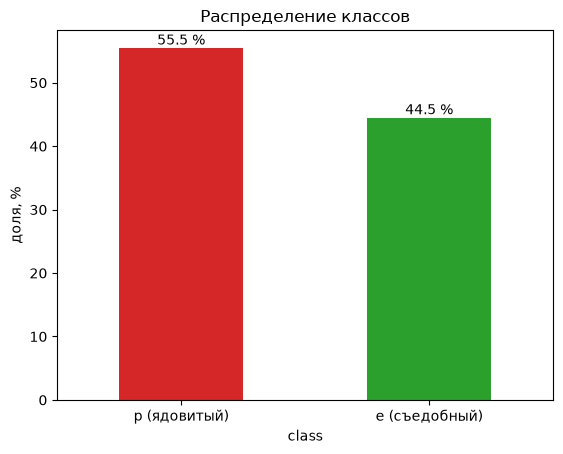

In [82]:
class_share = df["class"].value_counts(normalize=True).mul(100)
class_share = class_share.rename(index={"p": "p (ядовитый)", "e": "e (съедобный)"})

ax = class_share.plot.bar(rot=0, color=["tab:red", "tab:green"])
ax.set_ylabel("доля, %")
ax.set_title("Распределение классов")
ax.bar_label(ax.containers[0], fmt="%.1f %%")
plt.show()

Диаграмма подтверждает вывод выше: ядовитых грибов 55.5 %, съедобных 44.5 %. Классы почти сбалансированы, при разделении выборки используем стратификацию по `class`.

**Числовые признаки в разрезе класса**

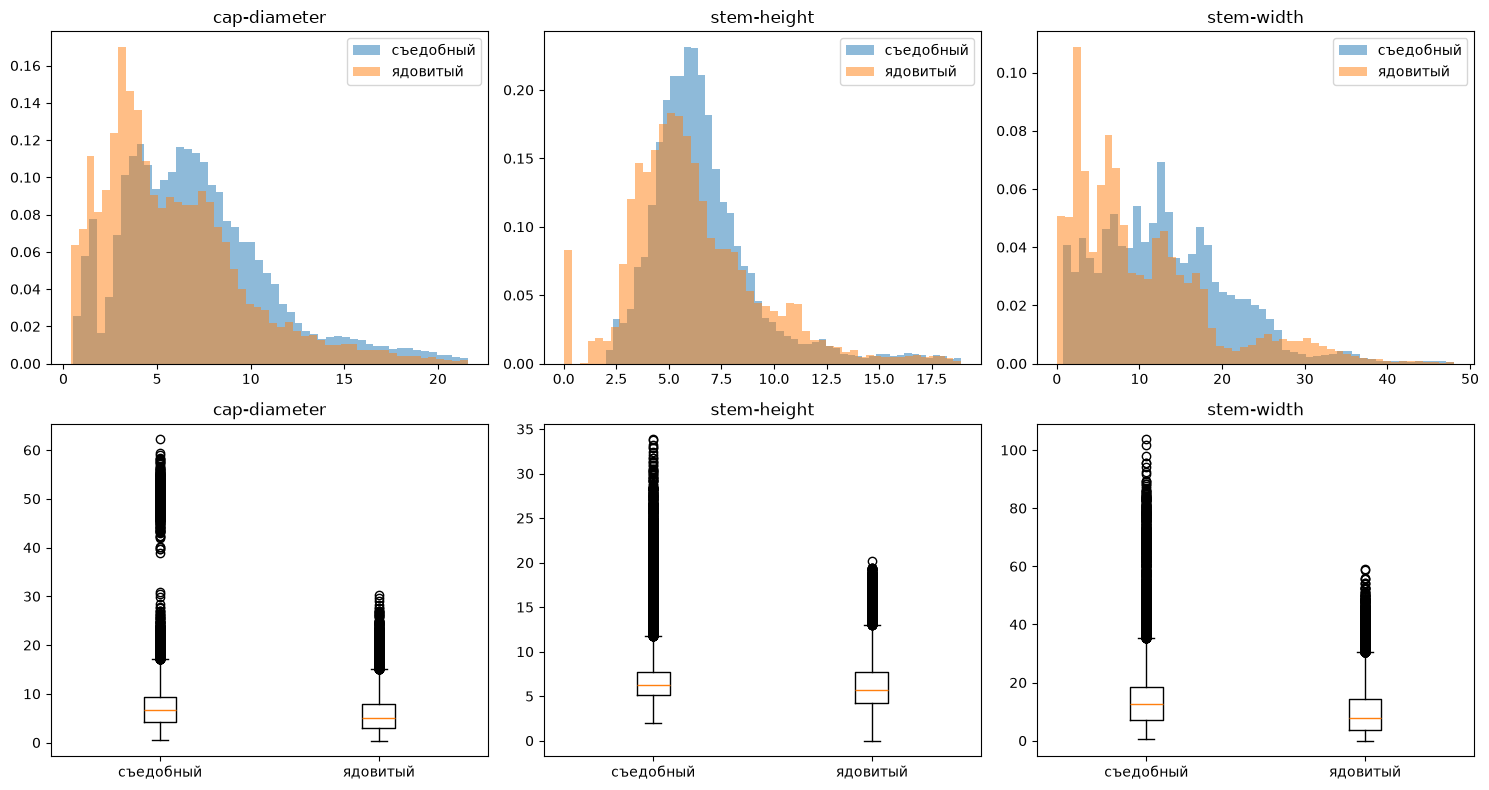

,cap-diameter,stem-height,stem-width
class,,,
e,6.71,6.24,12.59
p,4.98,5.64,7.68


In [83]:
num_cols = ["cap-diameter", "stem-height", "stem-width"]
classes = {"e": "съедобный", "p": "ядовитый"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    # Гистограммы обрезаем по 99-му перцентилю, чтобы хвост не сжимал основную часть распределения
    upper = df[col].quantile(0.99)
    for cls, name in classes.items():
        values = df.loc[df["class"] == cls, col].dropna()
        axes[0, i].hist(values[values <= upper], bins=50, alpha=0.5, density=True, label=name)
    axes[0, i].set_title(col)
    axes[0, i].legend()

    axes[1, i].boxplot(
        [df.loc[df["class"] == cls, col].dropna() for cls in classes],
        tick_labels=list(classes.values()),
    )
    axes[1, i].set_title(col)

plt.tight_layout()
plt.show()

df.groupby("class")[num_cols].median().round(2)

- Съедобные грибы в целом крупнее ядовитых: медиана диаметра шляпки 6.71 см против 4.98 см, медиана ширины ножки 12.59 мм против 7.68 мм.
- По высоте ножки классы различаются слабо: медиана 6.24 см против 5.64 см.
- Распределения классов сильно перекрываются, поэтому по одному размеру гриб не классифицировать. Но `cap-diameter` и `stem-width` должны быть полезны модели.
- У обоих классов во всех трёх признаках есть выбросы вверх, но самые крупные экземпляры только съедобные. Максимум диаметра шляпки у ядовитых 30.34 см, у съедобных 62.34 см, и все 353 гриба со шляпкой от 35 см съедобные. Максимальная высота ножки у ядовитых 20.19 см, у съедобных 33.92 см. Это не обязательно ошибки, а возможно отдельный вид крупных грибов, поэтому на этапе детекции выбросов удалять их вслепую нельзя.
- Нулевая высота ножки встречается только у ядовитых (грибы без ножки, см. выше), это видно по отдельному столбику у нуля на гистограмме.

**Связь пропусков с классом**

In [84]:
rows = []
for col in df.columns[df.isna().any()]:
    is_na = df[col].isna()
    rows.append({
        "признак": col,
        "пропусков, %": is_na.mean() * 100,
        "ядовитых среди пропусков, %": (df.loc[is_na, "class"] == "p").mean() * 100,
        "ядовитых среди заполненных, %": (df.loc[~is_na, "class"] == "p").mean() * 100,
    })

missing_vs_class = pd.DataFrame(rows).set_index("признак")
missing_vs_class["разница, п.п."] = (
    missing_vs_class["ядовитых среди пропусков, %"] - missing_vs_class["ядовитых среди заполненных, %"]
)
missing_vs_class.round(1).sort_values("разница, п.п.", key=abs, ascending=False)

,"пропусков, %","ядовитых среди пропусков, %","ядовитых среди заполненных, %","разница, п.п."
признак,,,,
spore-print-color,89.6,53.5,72.2,-18.7
ring-type,4.0,42.9,56.0,-13.2
stem-surface,62.4,50.9,63.1,-12.2
veil-type,94.8,54.9,66.7,-11.8
gill-attachment,16.2,64.3,53.8,10.5
stem-root,84.4,54.1,63.0,-8.9
cap-surface,23.1,52.5,56.4,-3.9
veil-color,87.9,55.3,57.1,-1.9
gill-spacing,41.0,56.3,54.9,1.4


Для каждого признака сравнили долю ядовитых грибов среди строк с пропуском и среди заполненных строк (в среднем по датасету ядовитых 55.5 %).

- **Пропуск связан с классом:** `spore-print-color` (53.5 % ядовитых среди пропусков против 72.2 % среди заполненных), `ring-type` (42.9 % против 56.0 %), `stem-surface` (50.9 % против 63.1 %), `veil-type` (54.9 % против 66.7 %), `gill-attachment` (64.3 % против 53.8 %), `stem-root` (54.1 % против 63.0 %). Здесь сам факт пропуска несёт информацию о классе.
- **Пропуск почти не связан с классом** (разница меньше 2 п.п.): `stem-height`, `stem-width`, `gill-spacing`, `veil-color`.

**Вывод для этапа обработки:** в признаках первой группы пропуск лучше сохранить как отдельную категорию («неизвестно») или добавить признак-индикатор пропуска, а не заполнять модой, иначе эта информация потеряется. Признаки второй группы можно заполнять обычными способами (медианой или модой).

**Категориальные признаки в разрезе класса**

In [85]:
cat_cols = [col for col in df.columns if df[col].dtype != "float64" and col not in ("class", "veil-type")]
p_overall = (df["class"] == "p").mean() * 100

rows = []
for col in cat_cols:
    p_share = df.groupby(col)["class"].agg(lambda s: (s == "p").mean() * 100)
    counts = df[col].value_counts()
    rows.append({
        "признак": col,
        "значений": len(p_share),
        "мин. доля ядовитых, %": p_share.min(),
        "макс. доля ядовитых, %": p_share.max(),
        "только ядовитые": ", ".join(f"{v} ({counts[v]})" for v in p_share[p_share == 100].index),
        "только съедобные": ", ".join(f"{v} ({counts[v]})" for v in p_share[p_share == 0].index),
    })

cat_vs_class = pd.DataFrame(rows).set_index("признак")
cat_vs_class["разброс, п.п."] = cat_vs_class["макс. доля ядовитых, %"] - cat_vs_class["мин. доля ядовитых, %"]
cat_vs_class.round(1).sort_values("разброс, п.п.", ascending=False)

,значений,"мин. доля ядовитых, %","макс. доля ядовитых, %",только ядовитые,только съедобные,"разброс, п.п."
признак,,,,,,
stem-color,13,0.0,100.0,f (1059),b (173),100.0
veil-color,6,0.0,100.0,"e (181), k (353), n (525), u (353)",y (527),100.0
ring-type,8,0.0,100.0,z (2118),m (353),100.0
spore-print-color,7,0.0,100.0,"n (1059), r (171), u (182)",g (353),100.0
habitat,8,0.0,100.0,p (360),"u (115), w (353)",100.0
cap-color,12,20.8,88.9,,,68.1
stem-root,5,33.3,100.0,"c (706), f (1059), r (1412)",,66.7
stem-surface,8,41.1,100.0,"f (1059), g (1765), h (535)",,58.9
cap-surface,11,43.0,92.1,,,49.2


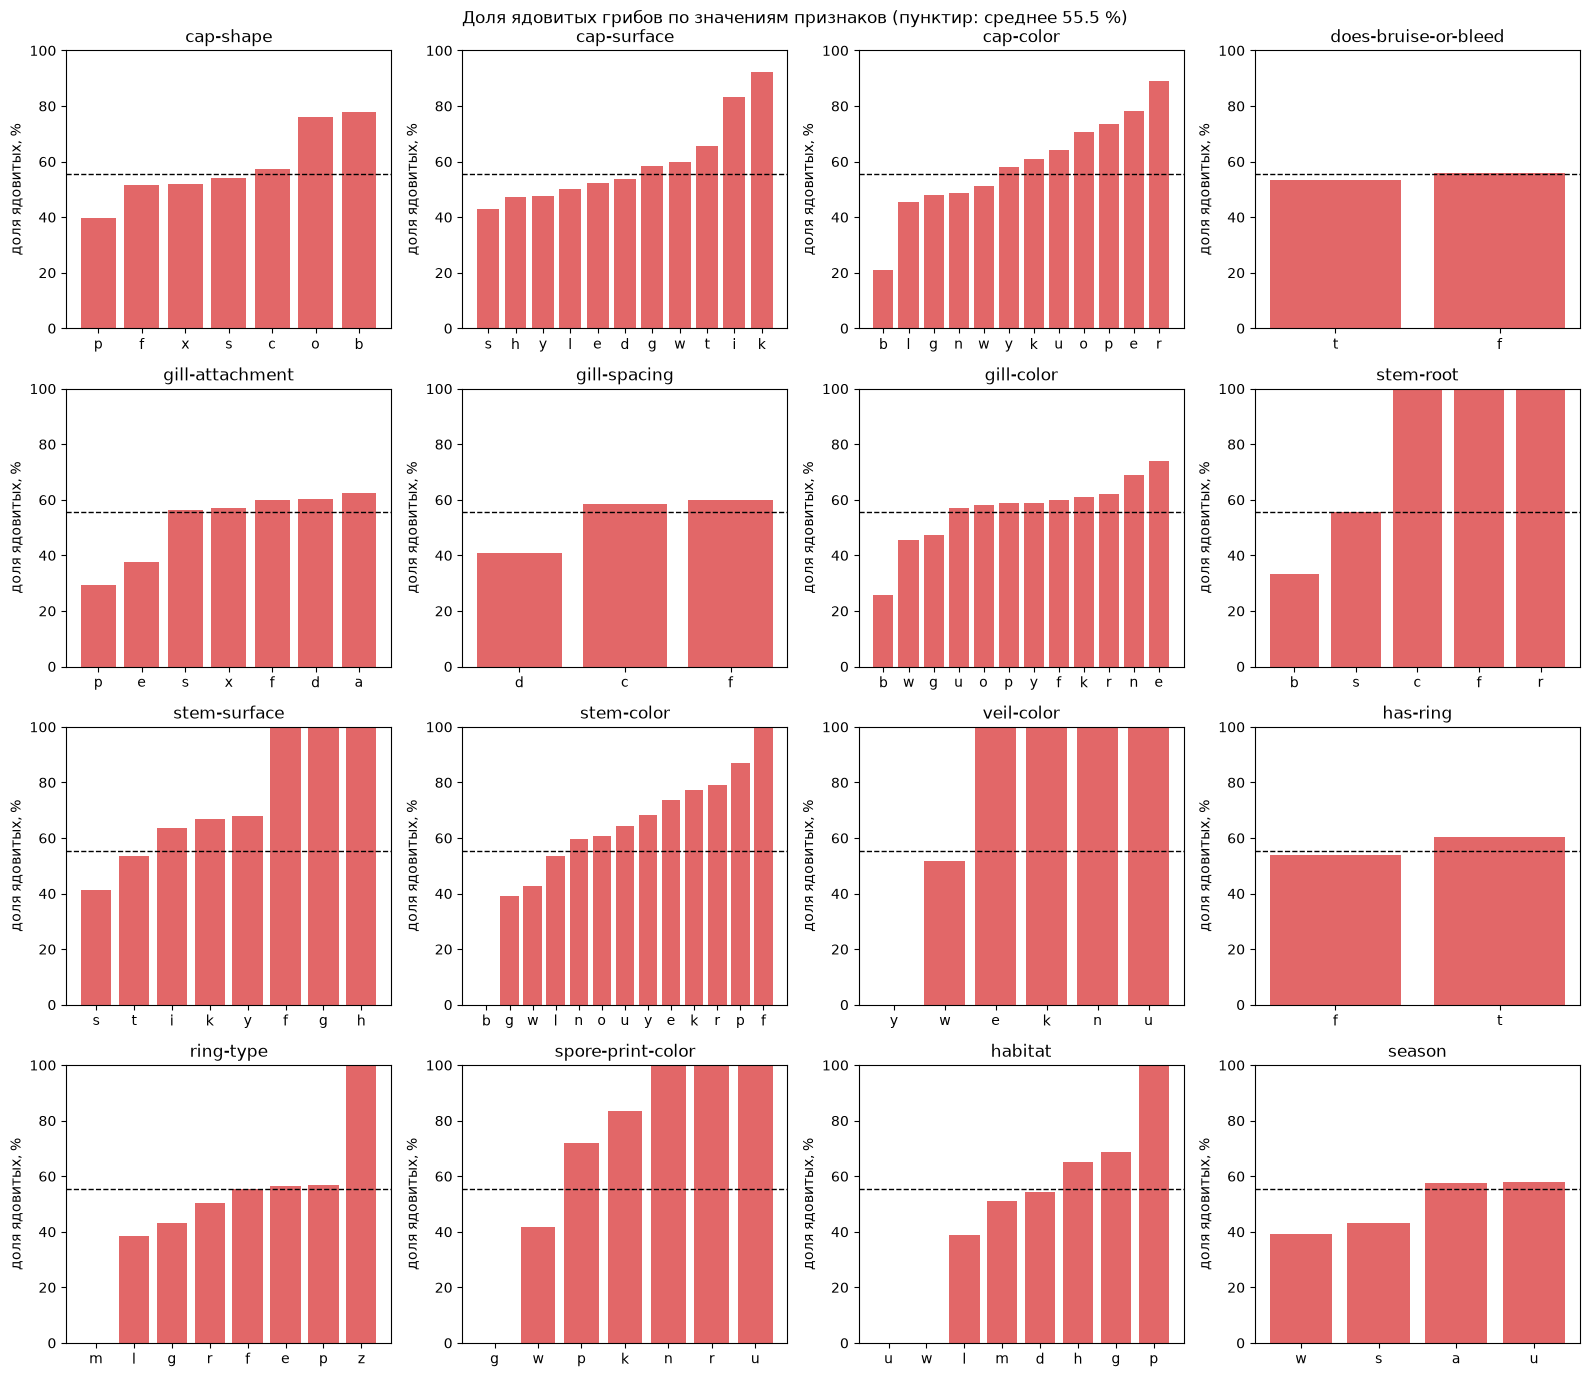

In [86]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, col in zip(axes.flat, cat_cols):
    p_share = df.groupby(col)["class"].agg(lambda s: (s == "p").mean() * 100).sort_values()
    ax.bar(p_share.index, p_share.values, color="tab:red", alpha=0.7)
    ax.axhline(p_overall, color="black", linestyle="--", linewidth=1)
    ax.set_ylim(0, 100)
    ax.set_title(col)
    ax.set_ylabel("доля ядовитых, %")

fig.suptitle(f"Доля ядовитых грибов по значениям признаков (пунктир: среднее {p_overall:.1f} %)")
plt.tight_layout()
plt.show()

Для каждого значения категориального признака посчитали долю ядовитых грибов (`veil-type` не рассматриваем, он константный).

- **Есть значения, полностью определяющие класс.** Например, `ring-type = z` (2 118 грибов), `stem-color = f`, `spore-print-color = n` (по 1 059) и `habitat = p` (360) встречаются только у ядовитых. `ring-type = m`, `habitat = w`, `spore-print-color = g` (по 353), `veil-color = y` (527) и `stem-color = b` (173) встречаются только у съедобных. Размеры таких групп часто кратны 353, поэтому, вероятно, датасет собран из отдельных видов грибов, и эти значения указывают на конкретный вид.
- **Сильно связаны с классом** `cap-color` (от 20.8 % ядовитых у бежевых шляпок до 88.9 % у зелёных), `stem-root`, `stem-surface`, `cap-surface` и `gill-color`. Но у `stem-root`, `stem-surface`, `veil-color` и `spore-print-color` много пропусков, и чистые значения покрывают небольшую часть выборки.
- **Слабо связаны с классом** `does-bruise-or-bleed` (разброс 2.6 п.п.) и `has-ring` (6.6 п.п.), а также `season` и `gill-spacing` (около 19 п.п.).

Ни один признак не разделяет классы целиком, но комбинация категориальных признаков с размерами должна дать модели хороший сигнал.

## 1.3. Разделение выборки на обучающую и тестовую выборки

In [ ]:
# Полные дубликаты удаляем до разделения: иначе одна и та же строка может попасть и в train, и в test
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns="class")
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print("Вся выборка:", X.shape)
print("train:", X_train.shape)
print("test: ", X_test.shape)

Вся выборка: (60973, 20)
train: (48778, 20)
test:  (12195, 20)


In [88]:
pd.DataFrame({
    "вся выборка": y.value_counts(normalize=True),
    "train": y_train.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}).mul(100).round(2)

,вся выборка,train,test
class,,,
p,55.42,55.42,55.42
e,44.58,44.58,44.58


Перед разделением удалили 96 полных дубликатов. Если этого не сделать, копии одной строки могут попасть и в обучающую, и в тестовую выборку, и оценка модели на тесте окажется завышенной. После удаления осталось 60 973 строки.

Выборку разделили на обучающую (80 %) и тестовую (20 %) со стратификацией по `class`, поэтому соотношение классов в train и test совпадает с исходным (55.4 % ядовитых). `random_state=SEED` делает разбиение воспроизводимым.

Дальнейшую обработку (заполнение пропусков, кодирование, детекцию выбросов) будем настраивать только на `X_train`, а к `X_test` применять уже обученные преобразования, чтобы не было утечки.

## 1.4. Обработка вещественных признаков (заполнение пропусков)

## 1.5. Кодирование категориальных признаков

## 1.6. Детекция выбросов и аномалий в данных

## 1.7. Подведение итогов раздела 1
<!-- А таких разделах обычно подытоживается вся информация о тех действиях, которые вы делали в разделе -->

# 2. Генерация новых признаков

## 2.1. Корреляционный анализ входных признаков (построение тепловых карт корреляции)

## 2.2. Исправление проблемы мультиколлинеарности в данных

## 2.3. Скалирование данных

## 2.4. Подведение итогов раздела 2
<!-- А таких разделах обычно подытоживается вся информация о тех действиях, которые вы делали в разделе -->

# 3. Выбор моделей ML и метрик

`ячейки для выбора моделей ML`
<!-- Третий раздел самый богатый на писанину. Вам необходимо сначала обосновать выбор моделей, а затем все отобранные модели описать (расписать концептуально, как они работают) -->

`ячейки для выбора метрик`
<!-- И снова писанина: необходимо не только описать, какие метрики вы используете, но привести формулы их вычисления -->

In [89]:
# ячейка для импорта моделей из пула

In [90]:
# ячейки для формирования сеток гиперпараметров

In [91]:
# ячейка для импорта метрик из пула

# 4. Обучение моделей ML и подбор гиперпараметров

In [92]:
# ячейки для подбора гиперпараметров и обучения лучших моделей

# 5. Вычисление метрик на новых данных

In [93]:
# ячейки для вычисления метрик на лучших моделях и их сопоставление

# 6. Результат работы

`ячейка для подведения итогов по всей работе`
<!-- Тут обычно пишется, какая модель показала себя лучше, с какими метриками и рекомендуется ли ее выводить в прод -->